In [1]:
import numpy as np
import functools
import pickle
import time
import torch
from matplotlib import pyplot as pp

In [2]:
with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_sampled_random_with_noise = data['data_sampled_random_with_noise']
model_name = 'No external force'
sparsity   = 'sparsity 1.667Hz'

t_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['t'], dtype=torch.float64)
y_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['x'], dtype=torch.float64)

n = len(t_obs)
p = 1
print(f"n = {n}")

n = 100


In [3]:
m_true      = 2.0
c_true      = 0.3
k_true      = 0.2
delta_true  = c_true / (2 * m_true)
omega0_true = np.sqrt(k_true / m_true)

sigma = 0.1
R     = sigma ** 2

print(f"true delta  = {delta_true:.4f}")
print(f"true omega0 = {omega0_true:.4f}")
print(f"R           = {R}")

true delta  = 0.0750
true omega0 = 0.3162
R           = 0.010000000000000002


In [4]:
K              = 4
h              = (t_obs[1] - t_obs[0]).item()
theorem2_bound = n ** (-5 / (2 * K))
m_sub          = int(np.ceil(h / theorem2_bound))
step_size      = h / m_sub

print(f"m_sub     = {m_sub}")
print(f"step_size = {step_size:.4f}s")

m_sub     = 11
step_size = 0.0546s


In [5]:
def msd(t, y, delta, omega0):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float64)
    x, v = y[0], y[1]
    return torch.stack([v, -2*delta*v - omega0**2*x])

def rk4_integrate(f, t_eval, y0, m_sub):
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0, dtype=torch.float64)
    if not torch.is_tensor(t_eval):
        t_eval = torch.tensor(t_eval, dtype=torch.float64)
    Y = [y0]
    y = y0
    for i in range(1, len(t_eval)):
        dt = (t_eval[i] - t_eval[i-1]).item()
        h  = dt / m_sub
        yi = y
        ti = t_eval[i-1].item()
        for _ in range(m_sub):
            k1 = f(ti,       yi            )
            k2 = f(ti + h/2, yi + h/2 * k1)
            k3 = f(ti + h/2, yi + h/2 * k2)
            k4 = f(ti + h,   yi + h   * k3)
            yi = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
            ti += h
        y = yi
        Y.append(y)
    return torch.stack(Y)

In [6]:
# LAP-style prior on x1
mu_x1 = y_obs[0].item()
c     = 100.0
a     = 0.1
b     = 0.01

# MAP-Laplace-style prior on theta
theta_prior = torch.tensor([0.10, 0.35], dtype=torch.float64)
D           = torch.diag(torch.tensor([0.20, 0.40], dtype=torch.float64))

# sanity check
theta_true_t = torch.tensor([delta_true, omega0_true], dtype=torch.float64)
z_true       = torch.linalg.solve(D, theta_true_t - theta_prior)
print(f"theta_prior = {theta_prior.numpy()}")
print(f"D scales    = {torch.diag(D).numpy()}")
print(f"z_true      = {z_true.numpy()}  (should be O(1))")

theta_prior = [0.1  0.35]
D scales    = [0.2 0.4]
z_true      = [-0.125      -0.08443058]  (should be O(1))


In [7]:
def compute_gn(x_pred, y_obs):
    if not torch.is_tensor(x_pred):
        x_pred = torch.tensor(x_pred, dtype=torch.float64)
    if not torch.is_tensor(y_obs):
        y_obs  = torch.tensor(y_obs,  dtype=torch.float64)
    return torch.mean((y_obs - x_pred)**2)

def find_x1hat_torch(delta, omega0):
    x1 = torch.tensor([mu_x1], requires_grad=True, dtype=torch.float64)
    optimizer = torch.optim.LBFGS([x1], lr=1.0, max_iter=100)

    def closure():
        optimizer.zero_grad()
        f      = functools.partial(msd, delta=delta, omega0=omega0)
        Y      = rk4_integrate(f, t_obs,
                     torch.stack([x1[0], torch.tensor(0.0, dtype=torch.float64)]),
                     m_sub)
        gn     = compute_gn(Y[:, 0], y_obs)
        loss   = n * gn + (x1[0] - mu_x1)**2 / c
        loss.backward()
        return loss

    optimizer.step(closure)
    return x1[0].detach()

# sanity check at true parameters
x1_hat_true = find_x1hat_torch(
    torch.tensor(delta_true, dtype=torch.float64),
    torch.tensor(omega0_true, dtype=torch.float64)
)
print(f"x1_hat at true theta = {x1_hat_true.item():.6f}")
print(f"true x1              = 1.0000")
print(f"mu_x1                = {mu_x1:.6f}")

x1_hat at true theta = 0.964120
true x1              = 1.0000
mu_x1                = 1.030245


In [12]:
def J(z):
    theta  = theta_prior + D @ z
    delta  = theta[0]
    omega0 = theta[1]

    delta_val  = delta.detach()
    omega0_val = omega0.detach()

    # find optimal x1 with no_grad
    with torch.no_grad():
        x1_hat_val = find_x1hat_torch(delta_val, omega0_val).item()

    f      = functools.partial(msd, delta=delta, omega0=omega0)
    Y      = rk4_integrate(f, t_obs,
                 torch.stack([
                     torch.tensor(x1_hat_val, dtype=torch.float64),
                     torch.tensor(0.0,        dtype=torch.float64)
                 ]),
                 m_sub)
    y_pred = Y[:, 0]

    J_data  = (1.0 / (2 * n * R)) * torch.sum((y_obs - y_pred) ** 2)
    J_prior = 0.5 * torch.dot(z, z)

    return J_data + J_prior

In [13]:
t_start = time.time()

z = torch.zeros(2, dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.LBFGS([z], lr=1.0, max_iter=500,
                               tolerance_grad=1e-9, tolerance_change=1e-12,
                               line_search_fn='strong_wolfe')

def closure():
    optimizer.zero_grad()
    loss = J(z)
    loss.backward()
    return loss

optimizer.step(closure)
t_map = time.time() - t_start

z_map     = z.detach().clone()
theta_map = (theta_prior + D @ z_map).detach()

print(f"MAP optimization time: {t_map:.2f}s")
print(f"z_MAP     = {z_map.numpy()}")
print(f"theta_MAP = {theta_map.numpy()}")
print(f"true theta= [{delta_true:.4f}, {omega0_true:.4f}]")
print(f"J(z_MAP)  = {J(z_map).item():.6f}")

MAP optimization time: 21.95s
z_MAP     = [-0.08136113 -0.08730672]
theta_MAP = [0.08372777 0.31507731]
true theta= [0.0750, 0.3162]
J(z_MAP)  = 0.447148


In [14]:
t_start     = time.time()
H           = torch.autograd.functional.hessian(J, z_map)
t_hess      = time.time() - t_start

Sigma_z     = torch.linalg.inv(H)
Sigma_theta = D @ Sigma_z @ D.T

print(f"Hessian time:  {t_hess:.2f}s")
print(f"Total time:    {t_map + t_hess:.2f}s")
print(f"Sigma_theta =\n{Sigma_theta.detach().numpy()}")
print(f"posterior std delta  = {Sigma_theta[0,0].sqrt().item():.6f}")
print(f"posterior std omega0 = {Sigma_theta[1,1].sqrt().item():.6f}")

Hessian time:  2.92s
Total time:    24.87s
Sigma_theta =
[[0.0029134  0.0016172 ]
 [0.0016172  0.00298845]]
posterior std delta  = 0.053976
posterior std omega0 = 0.054667


In [15]:
N_samples     = 1000
dist          = torch.distributions.MultivariateNormal(
                    theta_map.float(), Sigma_theta.float())
theta_samples = dist.sample((N_samples,)).double()

# remove unphysical samples
valid         = (theta_samples[:, 0] > 0) & (theta_samples[:, 1] > 0)
theta_samples = theta_samples[valid]
print(f"Valid samples: {valid.sum().item()}/{N_samples}")

delta_samples  = theta_samples[:, 0].numpy()
omega0_samples = theta_samples[:, 1].numpy()

delta_ci  = np.percentile(delta_samples,  [2.5, 97.5])
omega0_ci = np.percentile(omega0_samples, [2.5, 97.5])

print(f"δ   95% CI: [{delta_ci[0]:.4f}, {delta_ci[1]:.4f}]  true={delta_true:.4f}")
print(f"ω₀  95% CI: [{omega0_ci[0]:.4f}, {omega0_ci[1]:.4f}]  true={omega0_true:.4f}")

Valid samples: 932/1000
δ   95% CI: [0.0117, 0.1924]  true=0.0750
ω₀  95% CI: [0.2164, 0.4233]  true=0.3162


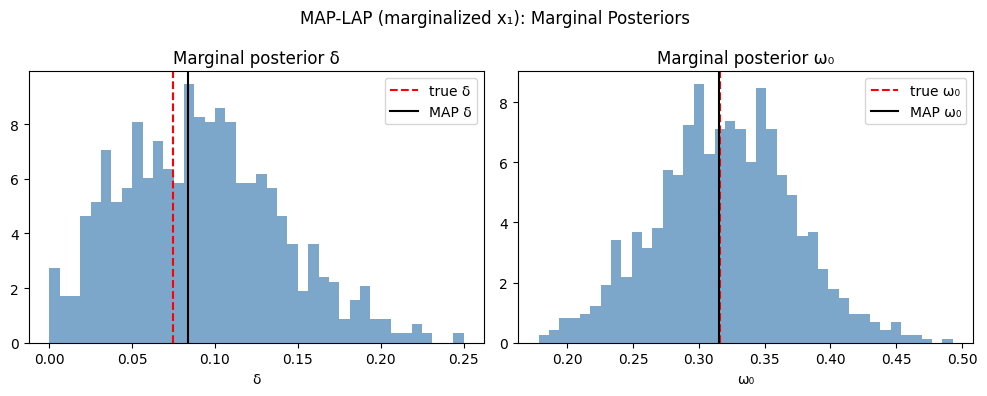

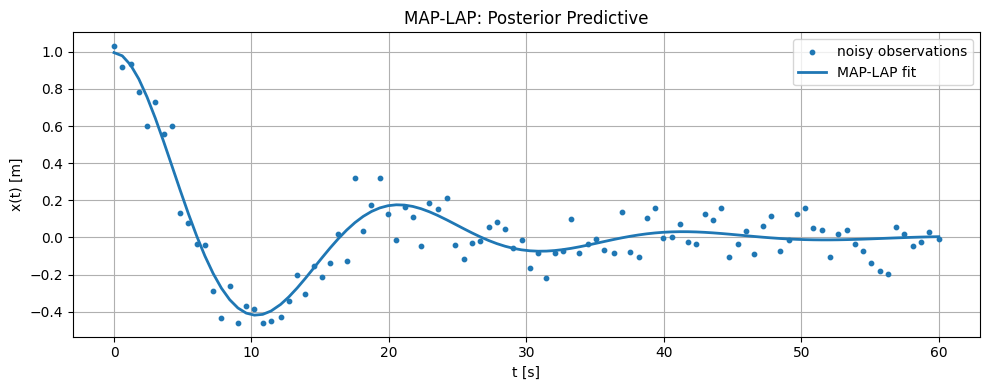


── Summary ──────────────────────────────────────
                               δ          ω₀
True                      0.0750      0.3162
MAP estimate              0.0837      0.3151
Posterior std             0.0540      0.0547
95% CI low                0.0117      0.2164
95% CI high               0.1924      0.4233
Total time                 24.87s
Saved: map_lap_results.npz


In [16]:
# --- 11.1 Marginal posteriors ---
fig, axes = pp.subplots(1, 2, figsize=(10, 4))

axes[0].hist(delta_samples, bins=40, density=True, alpha=0.7, color='steelblue')
axes[0].axvline(delta_true,          color='r', linestyle='--', label='true δ')
axes[0].axvline(theta_map[0].item(), color='k', linestyle='-',  label='MAP δ')
axes[0].set_xlabel('δ'); axes[0].set_title('Marginal posterior δ')
axes[0].legend()

axes[1].hist(omega0_samples, bins=40, density=True, alpha=0.7, color='steelblue')
axes[1].axvline(omega0_true,         color='r', linestyle='--', label='true ω₀')
axes[1].axvline(theta_map[1].item(), color='k', linestyle='-',  label='MAP ω₀')
axes[1].set_xlabel('ω₀'); axes[1].set_title('Marginal posterior ω₀')
axes[1].legend()

pp.suptitle('MAP-LAP (marginalized x₁): Marginal Posteriors')
pp.tight_layout(); pp.show()

# --- 11.2 Posterior predictive ---
x1_hat_map = find_x1hat_torch(theta_map[0], theta_map[1])
f_map      = functools.partial(msd, delta=theta_map[0], omega0=theta_map[1])
Y_map      = rk4_integrate(f_map, t_obs,
                 torch.stack([x1_hat_map, torch.tensor(0.0, dtype=torch.float64)]),
                 m_sub)

pp.figure(figsize=(10, 4))
pp.scatter(t_obs.numpy(), y_obs.numpy(), s=10,
           label='noisy observations', zorder=3)
pp.plot(t_obs.numpy(), Y_map[:, 0].detach().numpy(),
        lw=2, label='MAP-LAP fit')
pp.xlabel('t [s]'); pp.ylabel('x(t) [m]')
pp.title('MAP-LAP: Posterior Predictive')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

# --- 11.3 Summary ---
print("\n── Summary ──────────────────────────────────────")
print(f"{'':20s}  {'δ':>10s}  {'ω₀':>10s}")
print(f"{'True':20s}  {delta_true:>10.4f}  {omega0_true:>10.4f}")
print(f"{'MAP estimate':20s}  {theta_map[0].item():>10.4f}  {theta_map[1].item():>10.4f}")
print(f"{'Posterior std':20s}  {Sigma_theta[0,0].sqrt().item():>10.4f}  "
      f"{Sigma_theta[1,1].sqrt().item():>10.4f}")
print(f"{'95% CI low':20s}  {delta_ci[0]:>10.4f}  {omega0_ci[0]:>10.4f}")
print(f"{'95% CI high':20s}  {delta_ci[1]:>10.4f}  {omega0_ci[1]:>10.4f}")
print(f"{'Total time':20s}  {t_map + t_hess:>10.2f}s")

# --- 11.4 Save for comparison ---
x1_pred_map = Y_map[:, 0].detach().numpy()

np.savez('map_lap_results.npz',
    delta_samples  = delta_samples,
    omega0_samples = omega0_samples,
    x_pred         = x1_pred_map,
    theta_map      = theta_map.numpy(),
    t_obs          = t_obs.numpy(),
    y_obs          = y_obs.numpy(),
)
print("Saved: map_lap_results.npz")

In [17]:
map_lap = np.load('map_lap_results.npz')
map_lap_delta_samples  = map_lap['delta_samples']
map_lap_omega0_samples = map_lap['omega0_samples']
map_lap_x_pred         = map_lap['x_pred']
map_lap_theta_map      = map_lap['theta_map']

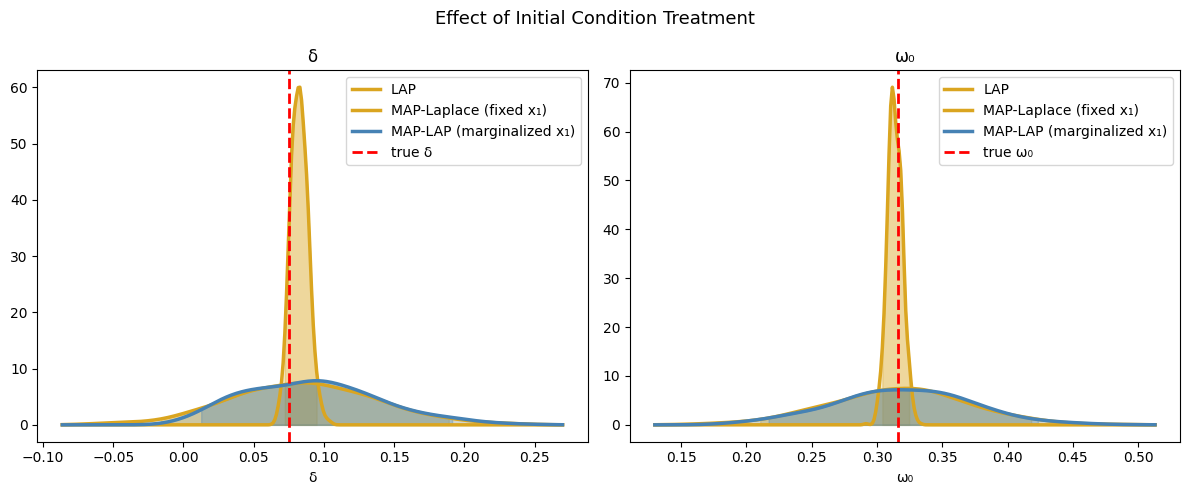

In [20]:
from scipy.stats import gaussian_kde

# Load original MAP-Laplace results
map_orig = np.load('map_results.npz')
lap = np.load('lap_results.npz')

# Shared x limits across both methods
delta_xmin  = min(map_orig['delta_samples'].min(),  delta_samples.min())  - 0.02
delta_xmax  = max(map_orig['delta_samples'].max(),  delta_samples.max())  + 0.02
omega0_xmin = min(map_orig['omega0_samples'].min(), omega0_samples.min()) - 0.02
omega0_xmax = max(map_orig['omega0_samples'].max(), omega0_samples.max()) + 0.02

def plot_kde(ax, samples, color, label, xmin, xmax):
    kde = gaussian_kde(samples, bw_method=0.3)
    xs  = np.linspace(xmin, xmax, 300)
    ys  = kde(xs)
    ax.plot(xs, ys, color=color, lw=2.5, label=label)
    ax.fill_between(xs, ys, alpha=0.2, color=color)
    ci      = np.percentile(samples, [2.5, 97.5])
    ci_mask = (xs >= ci[0]) & (xs <= ci[1])
    ax.fill_between(xs[ci_mask], ys[ci_mask], alpha=0.3, color=color)

fig, axes = pp.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Effect of Initial Condition Treatment', fontsize=13)

# delta
plot_kde(axes[0], lap['delta_samples'], 'goldenrod',
         'LAP', delta_xmin, delta_xmax)
plot_kde(axes[0], map_orig['delta_samples'], 'goldenrod',
         'MAP-Laplace (fixed x₁)', delta_xmin, delta_xmax)
plot_kde(axes[0], delta_samples, 'steelblue',
         'MAP-LAP (marginalized x₁)', delta_xmin, delta_xmax)
axes[0].axvline(delta_true, color='r', lw=2, linestyle='--', label='true δ')
axes[0].set_xlabel('δ'); axes[0].set_title('δ'); axes[0].legend()

# omega0
plot_kde(axes[1], lap['omega0_samples'], 'goldenrod',
         'LAP', omega0_xmin, omega0_xmax)
plot_kde(axes[1], map_orig['omega0_samples'], 'goldenrod',
         'MAP-Laplace (fixed x₁)', omega0_xmin, omega0_xmax)
plot_kde(axes[1], omega0_samples, 'steelblue',
         'MAP-LAP (marginalized x₁)', omega0_xmin, omega0_xmax)
axes[1].axvline(omega0_true, color='r', lw=2, linestyle='--', label='true ω₀')
axes[1].set_xlabel('ω₀'); axes[1].set_title('ω₀'); axes[1].legend()

pp.tight_layout()
pp.savefig('ic_effect_comparison.png', dpi=200, bbox_inches='tight')
pp.show()